# State Estimation with Physics-Encoded Neural Network 

Using a Context-Aware DeLaN model with log-Cholesky decomposition for inertia matrix and torque biases estimation, and residual torque prediction. Use inertia matrix and torque biases in Kalman Filter for state estimation.

Currently working with simulated data by `mpx`.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

seeds = range(5)

dataset_num = 8
dataset_path = Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"
trained_models_dir = Path("trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC")
name_template = ("epochs_1000_quad_mass_dataset_run8_input_values_{input_values}"
                 "_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_{seed}")

### Evalaute Input Data / Model

The input data for the LSTM could be either [joint_pos, joint_vel, tau_diff] or [base_orient, base_lin_vel, base_ang_vel, base_pos_z, tau_diff]. 

Evaluate offline (use ground truth values) and online performance (use KF estimations), combine results across seeds with mean and std for residual torque, residual bias, residual mass offline/online.

In [2]:
# offline evaluation
from utils.model_comparison import compare_input_variants, print_comparison

rows, refs = compare_input_variants(
    dataset_path, trained_models_dir, name_template, seeds=seeds,
    variants=("joint", "base_pos_z"))

best_offline = print_comparison(rows, refs)

  bewerte joint seed 0 ...


  bewerte joint seed 1 ...
  bewerte joint seed 2 ...
  bewerte joint seed 3 ...
  bewerte joint seed 4 ...
  bewerte base_pos_z seed 0 ...
  bewerte base_pos_z seed 1 ...
  bewerte base_pos_z seed 2 ...
  bewerte base_pos_z seed 3 ...
  bewerte base_pos_z seed 4 ...

Variante     Seed   tau-MSE  Bias-MSE  Masse-MAE  Masse-RMSE
------------------------------------------------------------
joint           0     0.163     0.070      0.138       0.260
joint           1     0.230     0.146      0.171       0.302
joint           2     0.191     0.095      0.170       0.268
joint           3     0.199     0.099      0.124       0.229
joint           4     0.191     0.061      0.138       0.241
base_pos_z      0     0.243     0.136      0.165       0.297
base_pos_z      1     0.167     0.061      0.140       0.253
base_pos_z      2     0.198     0.053      0.136       0.245
base_pos_z      3     0.196     0.051      0.121       0.233
base_pos_z      4     0.173     0.068      0.149       0.254

In [3]:
# online evaluation
# Alle 10 Modelle laufen IM Filter (online-realistisch, keine GT-Kanaele), ausgewertet
# auf den 12 Testlaeufen; Aggregation ueber die Seeds wie offline (Mittelwert +- Std).
#
# Unterschied zu offline: dort kommt das History-Fenster aus dem geloggten Datensatz,
# hier baut run_state_estimation es aus den Groessen des laufenden Filters. Fuer
# base_pos_z sind base_vel und p_z Filterschaetzungen -> der LSTM-Kontext und damit
# M~ / b~ sind kontaminiert; bei joint sind die History-Kanaele direkt gemessen.
# Diese Spalte entscheidet die Varianten-Frage, weil sie der Deployment-Bedingung
# entspricht. Laufzeit ~20 s pro Modell; cache_file=... setzen, um Wiederholungen
# zu ueberspringen.
from utils.model_comparison import compare_online, print_online_comparison

test_runs = [0, 1, 3, 8, 11, 13, 20, 25, 31, 33, 39, 45]   # Testsplit (seed 0)

rows_online = compare_online(
    dataset_path, trained_models_dir, name_template, sim_nums=test_runs, seeds=seeds,
    variants=("joint", "base_pos_z"))

best_online, agg_online = print_online_comparison(rows_online, rows_offline=rows)

best_variant = best_online["input_values"]
best_model_name = best_online["model"]

  online: joint seed 0 ...


/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_

### Evalaute KF estimation

The state estimation is tested with these methods:

1. Leg odometry alone
2. KF with nominal model (use only torque, inertia matrix, qfrc_bias for without payload)
3. KF with LogChol-CaDeLaC (proposed approach)
4. KF with gt residual model (ground truth values from simulation)

For each state parameter, plot the estimation for each method, along with the ground truth.

For each method, plot the estimation for each state parameter 

In [4]:
from utils.kf_utils import load_custom_dataset
from utils.report_plots import run_ladder_for_sim

cadelac_path = trained_models_dir / best_model_name   # bestes Modell aus der Online-Auswertung

# sim_num = TESTLAUF (nicht im Training gesehen). Gewaehlt: 45, groesste Nutzlast des
# Testsplits (4.64 kg) -> groesstes Residuum -> Unterschiede zwischen den Varianten am
# deutlichsten sichtbar. Weitere Testlaeufe: test_runs. Fuer den Fehlerfall siehe
# sim 11/13 (0.14 kg, ausserhalb der Trainingsabdeckung).
sim_num = 45
data = load_custom_dataset(dataset_path=dataset_path, sim_num=sim_num)
print(f"sim {sim_num}: Nutzlast {data['base_mass'][0] - 13.042:.3f} kg")

# nominal / cadelac / oracle -- identisches Q, R, est_mode 4, keine GT-Kanaele an den Filter
ladder = run_ladder_for_sim(data, cadelac_path)
print("Varianten:", sorted(ladder.keys()))

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
sim 45: Nutzlast 4.637 kg


Running state estimation:  13%|█▎        | 130/1000 [00:00<00:00, 1290.83it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1280.90it/s]


Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)


Running state estimation:  13%|█▎        | 129/1000 [00:00<00:00, 1285.74it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1282.30it/s]

Varianten: ['cadelac', 'nominal', 'oracle']


Methode              vel x   vel y   vel z   ang vel  Fz (Kontakt)
Leg odometry         0.061   0.026   0.101         -             -
nominal              0.038   0.039   0.214     0.050         37.44
cadelac              0.033   0.014   0.386     0.038         37.43
oracle               0.030   0.020   0.370     0.041         37.44


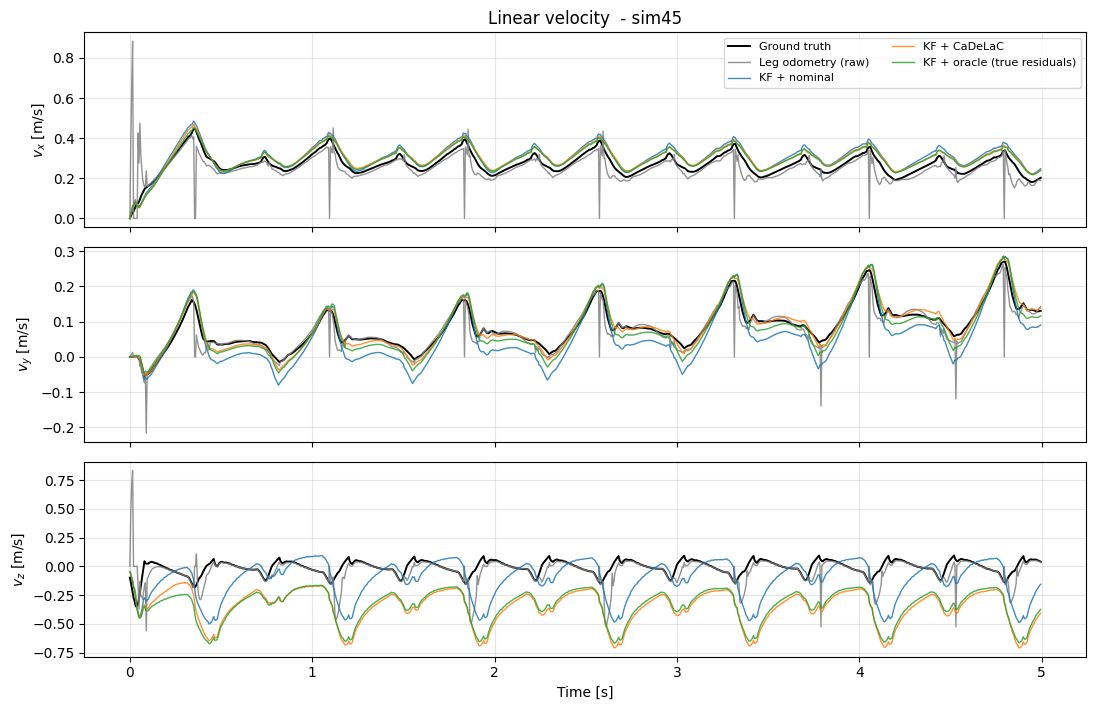

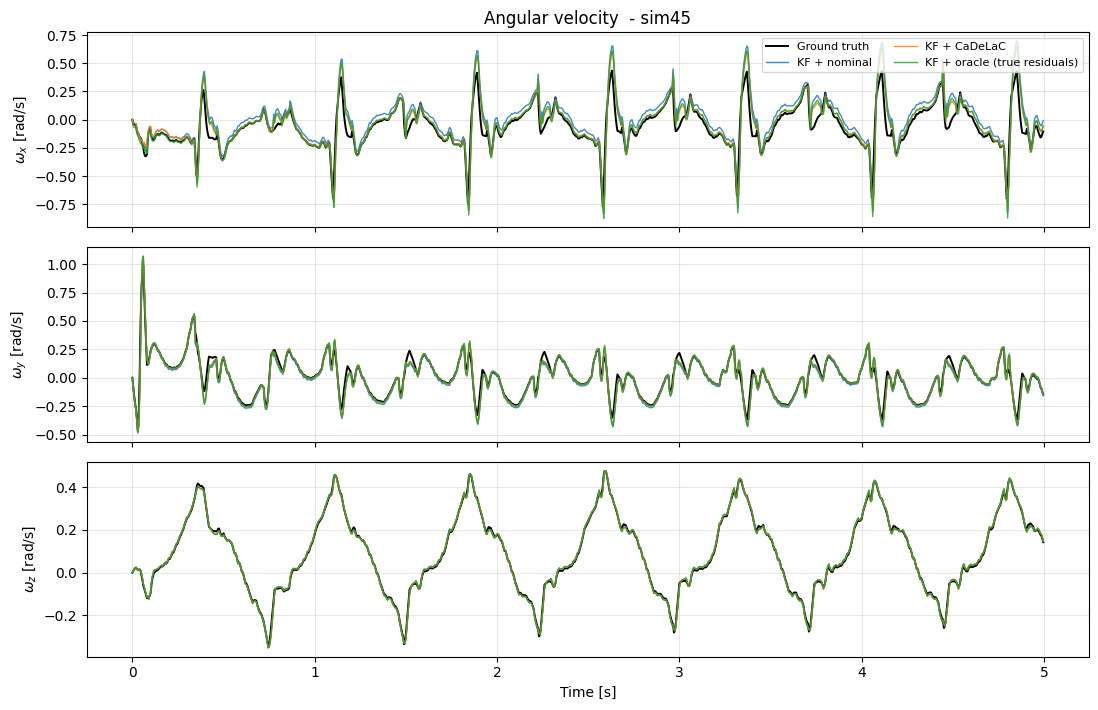

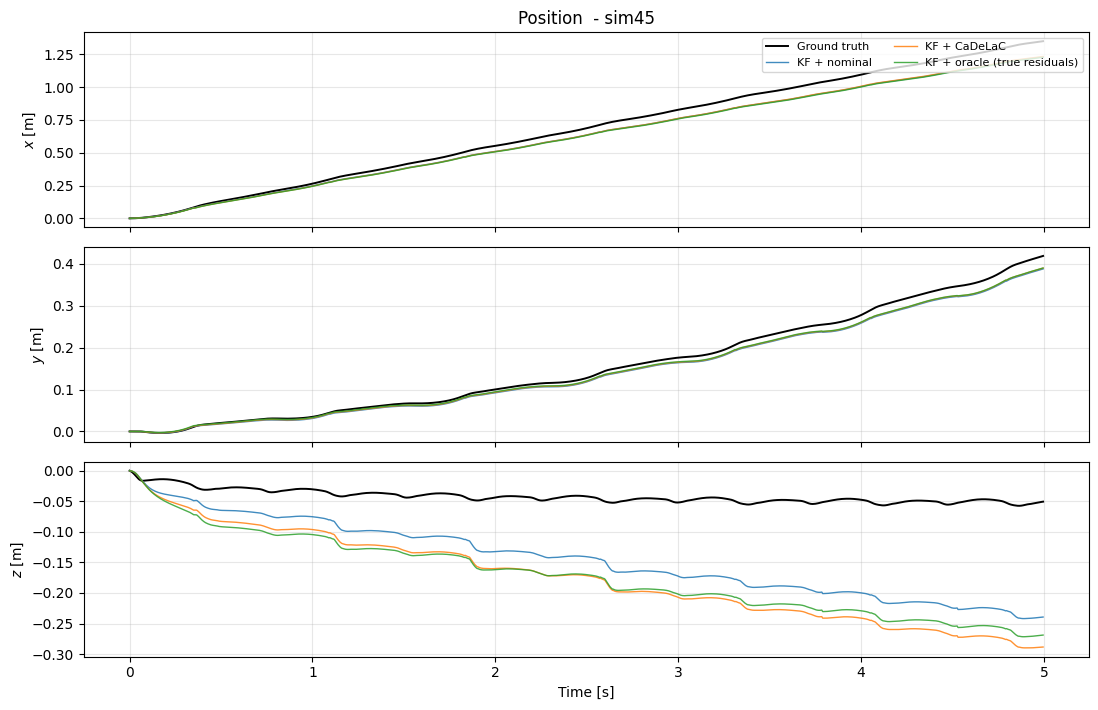

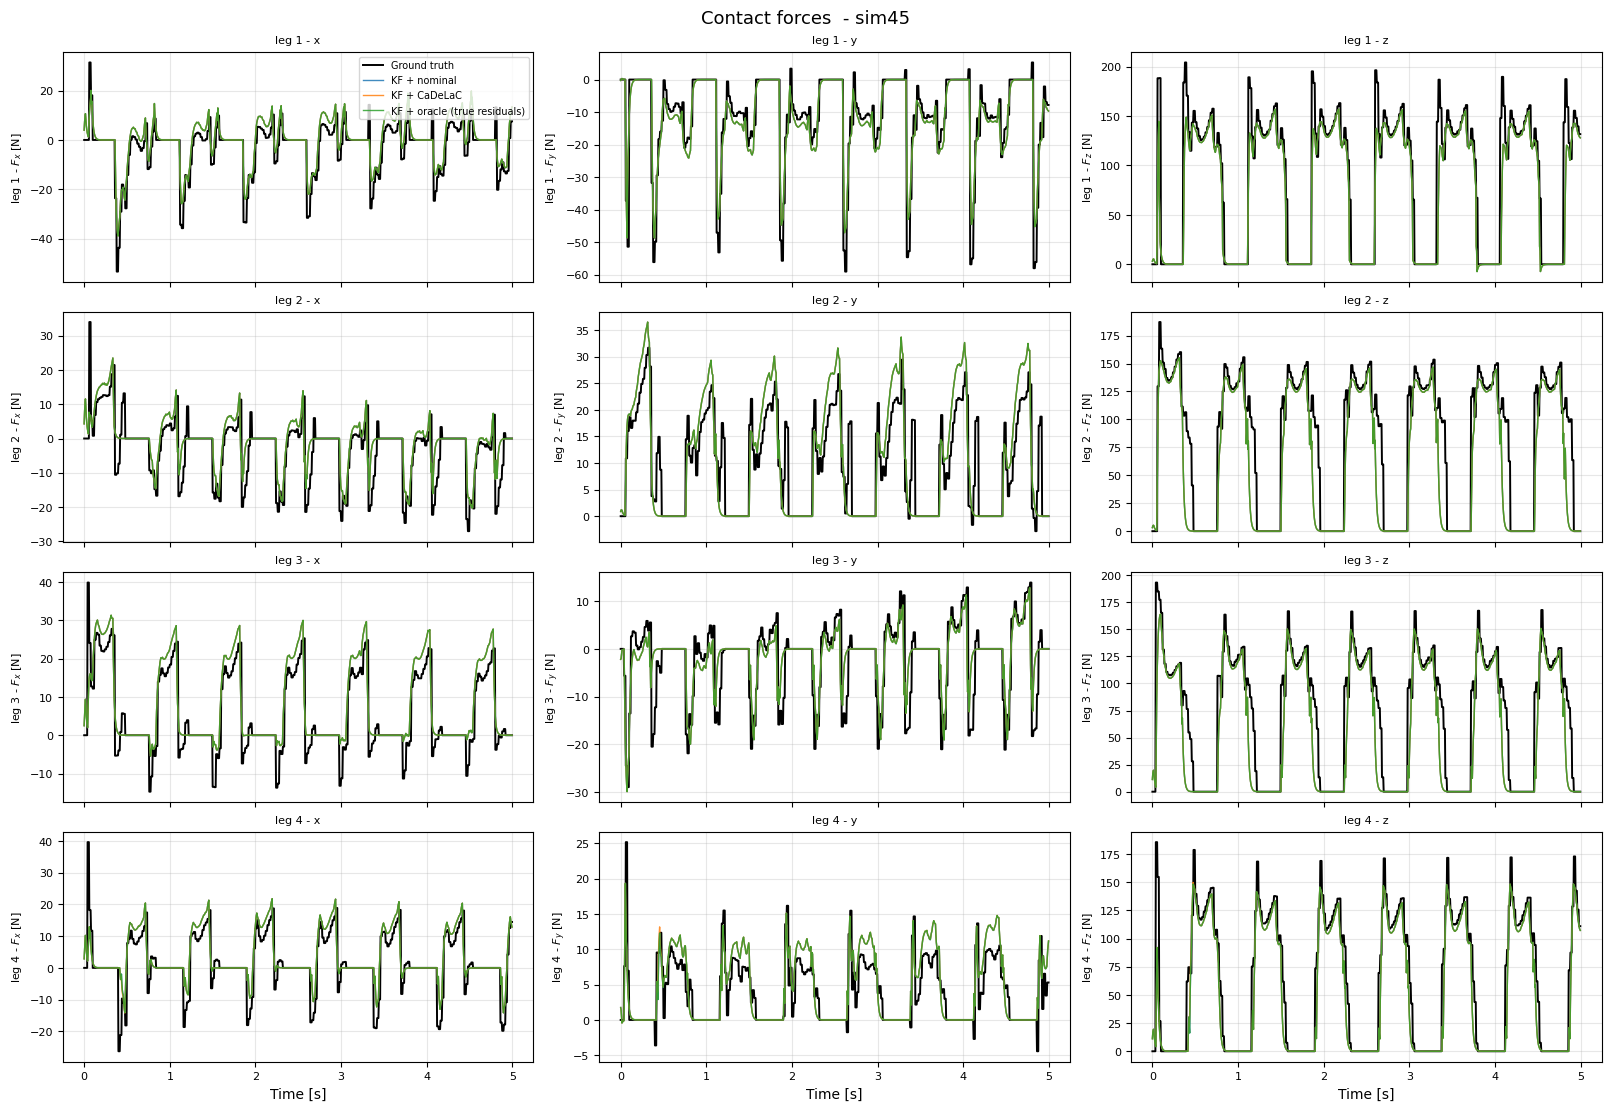

In [5]:
from utils.report_plots import plot_state_comparison
import numpy as np

# Ein Plot pro Zustandsparameter (PNG + PDF unter figures/report_part2/state_plots):
#   vel        5 Kurven: GT, Leg-Odometrie, KF+nominal, KF+CaDeLaC, KF+oracle
#   ang_vel    4 Kurven (Leg-Odometrie misst keine Winkelgeschwindigkeit)
#   pos        4 Kurven, startwert-bereinigt (relevant ist die Drift, nicht der Offset)
#   contact_f  4 Beine x 3 Komponenten, RMSE je Variante im Subplot-Titel
fig_dir = Path("figures/report_part2/state_plots")
figs = plot_state_comparison(data, ladder, sim_label=f" - sim{sim_num}", save_dir=fig_dir)

# RMSE-Zusammenfassung dieses Laufs (dieselben Groessen wie in den Plots)
gt_v, gt_w, gt_f = data["base_vel"], data["base_ang_vel"], data["contact_forces"]
mask = data["contact_states"].astype(bool)          # Kraefte nur bei echtem Bodenkontakt
rmse = lambda a, b: np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2, axis=0))

print(f"{'Methode':<18}{'vel x':>8}{'vel y':>8}{'vel z':>8}{'ang vel':>10}{'Fz (Kontakt)':>14}")
lo = rmse(next(iter(ladder.values()))["leg_odom_vel"], gt_v)
print(f"{'Leg odometry':<18}{lo[0]:>8.3f}{lo[1]:>8.3f}{lo[2]:>8.3f}{'-':>10}{'-':>14}")
for v, r in ladder.items():
    ve = rmse(r["vel_update"], gt_v)
    we = float(np.mean(rmse(r["ang_vel_update"], gt_w)))
    cf = np.asarray(r["c_force_update"]).reshape(len(gt_v), 4, 3)
    fz = float(np.sqrt(np.mean((cf[..., 2][mask] - gt_f[..., 2][mask]) ** 2)))
    print(f"{v:<18}{ve[0]:>8.3f}{ve[1]:>8.3f}{ve[2]:>8.3f}{we:>10.3f}{fz:>14.2f}")

### Sensitivity to the filter covariances

The ladder above uses the deployed $\mathbf{Q}$, $\mathbf{R}$. Those are misspecified: the contact-force "measurement" reconstructed from joint torques has an empirical RMSE of $\approx 33$ N, but $R_F = 10^{-2}$ declares a standard deviation of $0.1$ N — a factor $10^5$ of overconfidence. Likewise $Q_F = 10^{-3}$ asserts nearly constant contact forces although they swing by hundreds of N/s, while the leg odometry (true error $\approx 0.08$ m/s) is assigned $R_v = 0.1$, i.e. 16× *under*confidence.

Re-deriving the covariances from the measured error statistics gives $Q_F = 4 \approx (400\,\text{N/s} \cdot 5\,\text{ms})^2$, $R_F = 10^3 \approx 33^2$, $R_v = 6\cdot10^{-3} = 0.08^2$. The comparison below separates two questions that the first ladder conflates:

- **Does the dynamics correction hurt?** — only under the misspecified covariances. Correctly tuned, oracle and nominal coincide.
- **Why is $v_z$ poor at all?** — not a covariance issue. Even the nominal filter is worse than the raw leg-odometry measurement it fuses, because no sensor observes $v_z$ well. Only admitting an accelerometer changes that.

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Config      Methode      vel x   vel y   vel z  Drift [%/m]
-----------------------------------------------------------
(Messung)   leg odom     0.061   0.026   0.101            -


Running state estimation:   9%|▊         | 87/1000 [00:00<00:01, 864.99it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1157.17it/s]


...

Estimating contact state based on momentum
Estimating contact forces with joint torque
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)


Running state estimation:  15%|█▌        | 151/1000 [00:00<00:00, 1502.45it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1492.28it/s]


-----------------------------------------------------------
tuned+IMU   nominal      0.033   0.015   0.061         13.4
tuned+IMU   cadelac      0.033   0.015   0.061         13.4
tuned+IMU   oracle       0.033   0.015   0.061         13.4


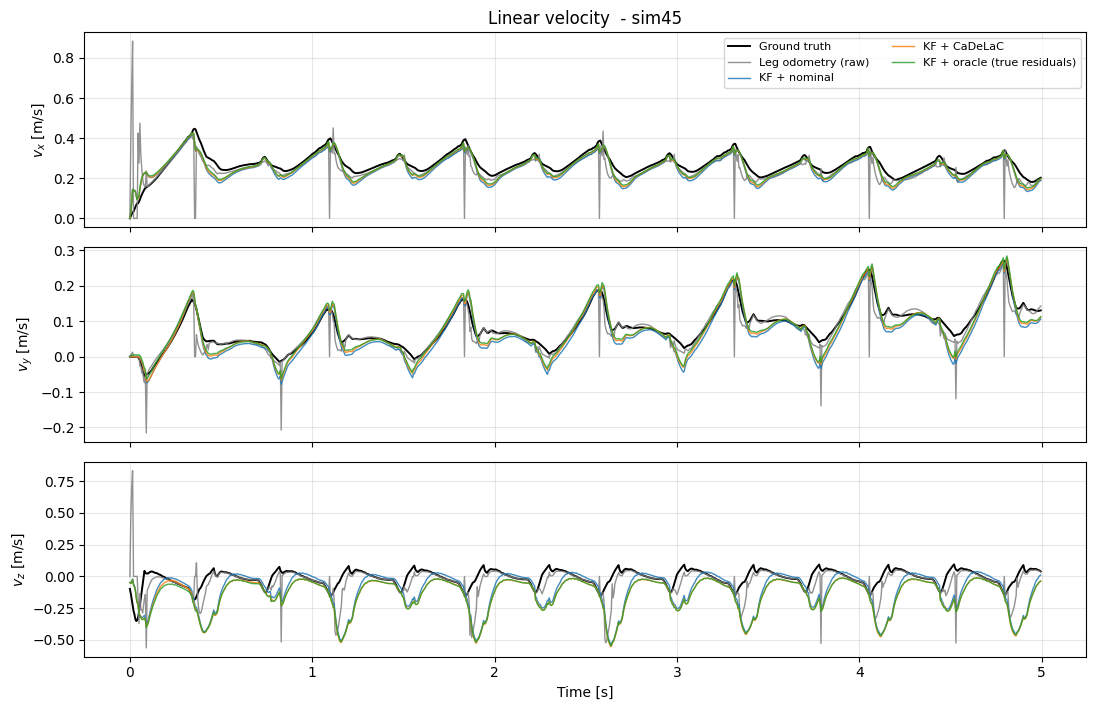

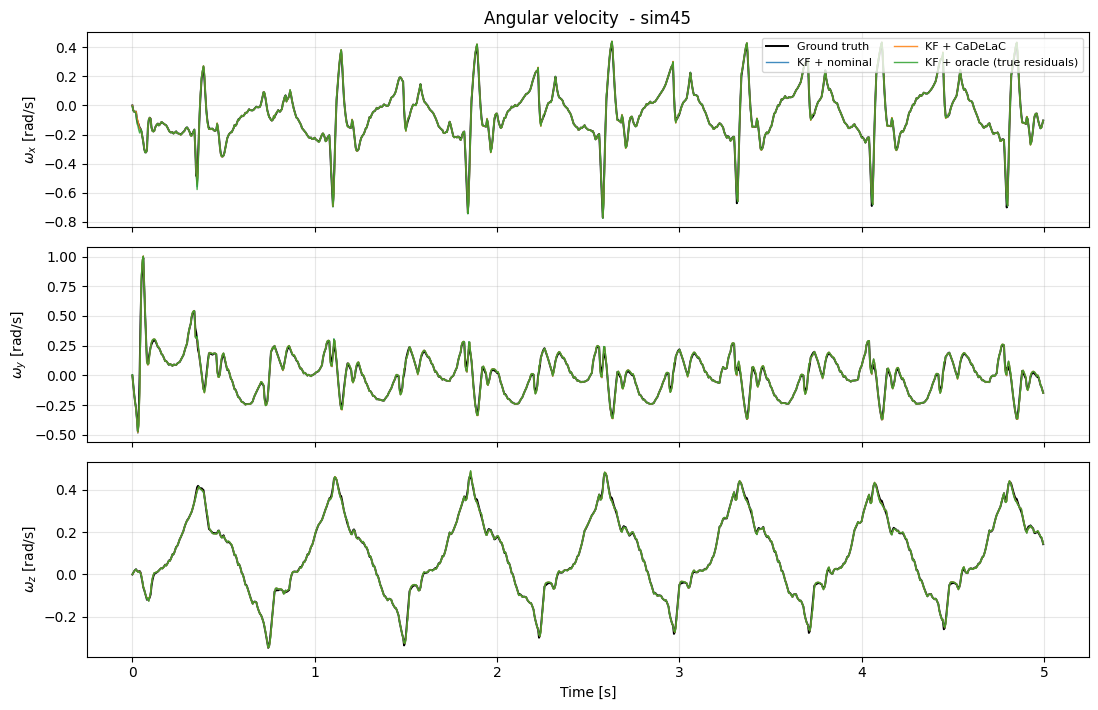

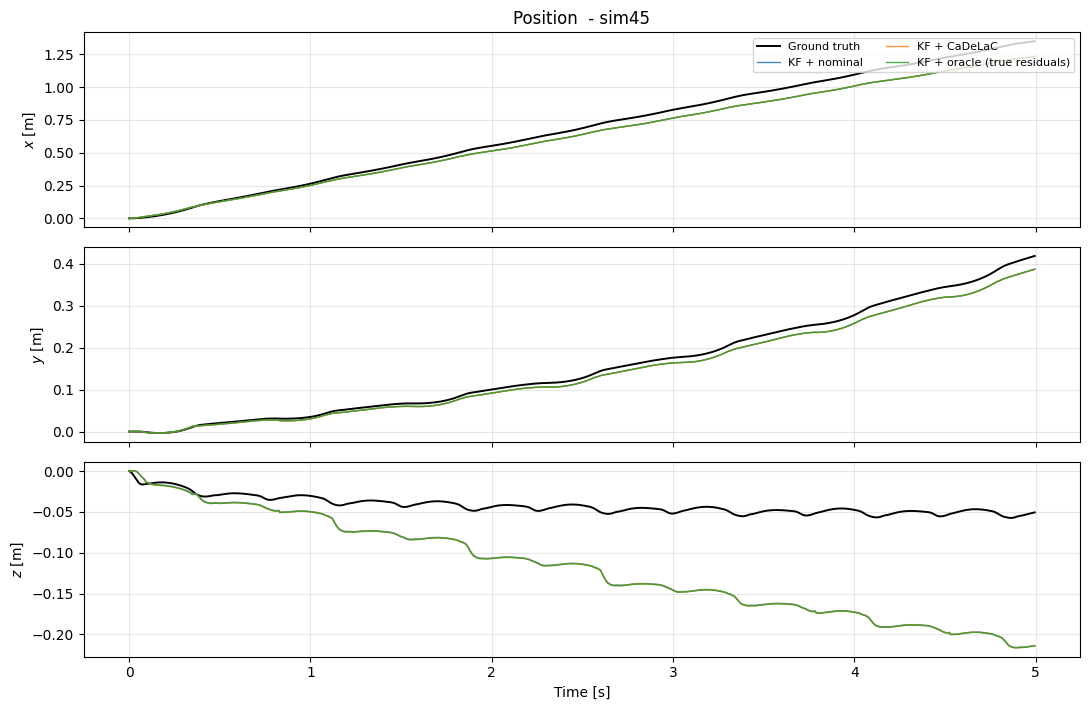

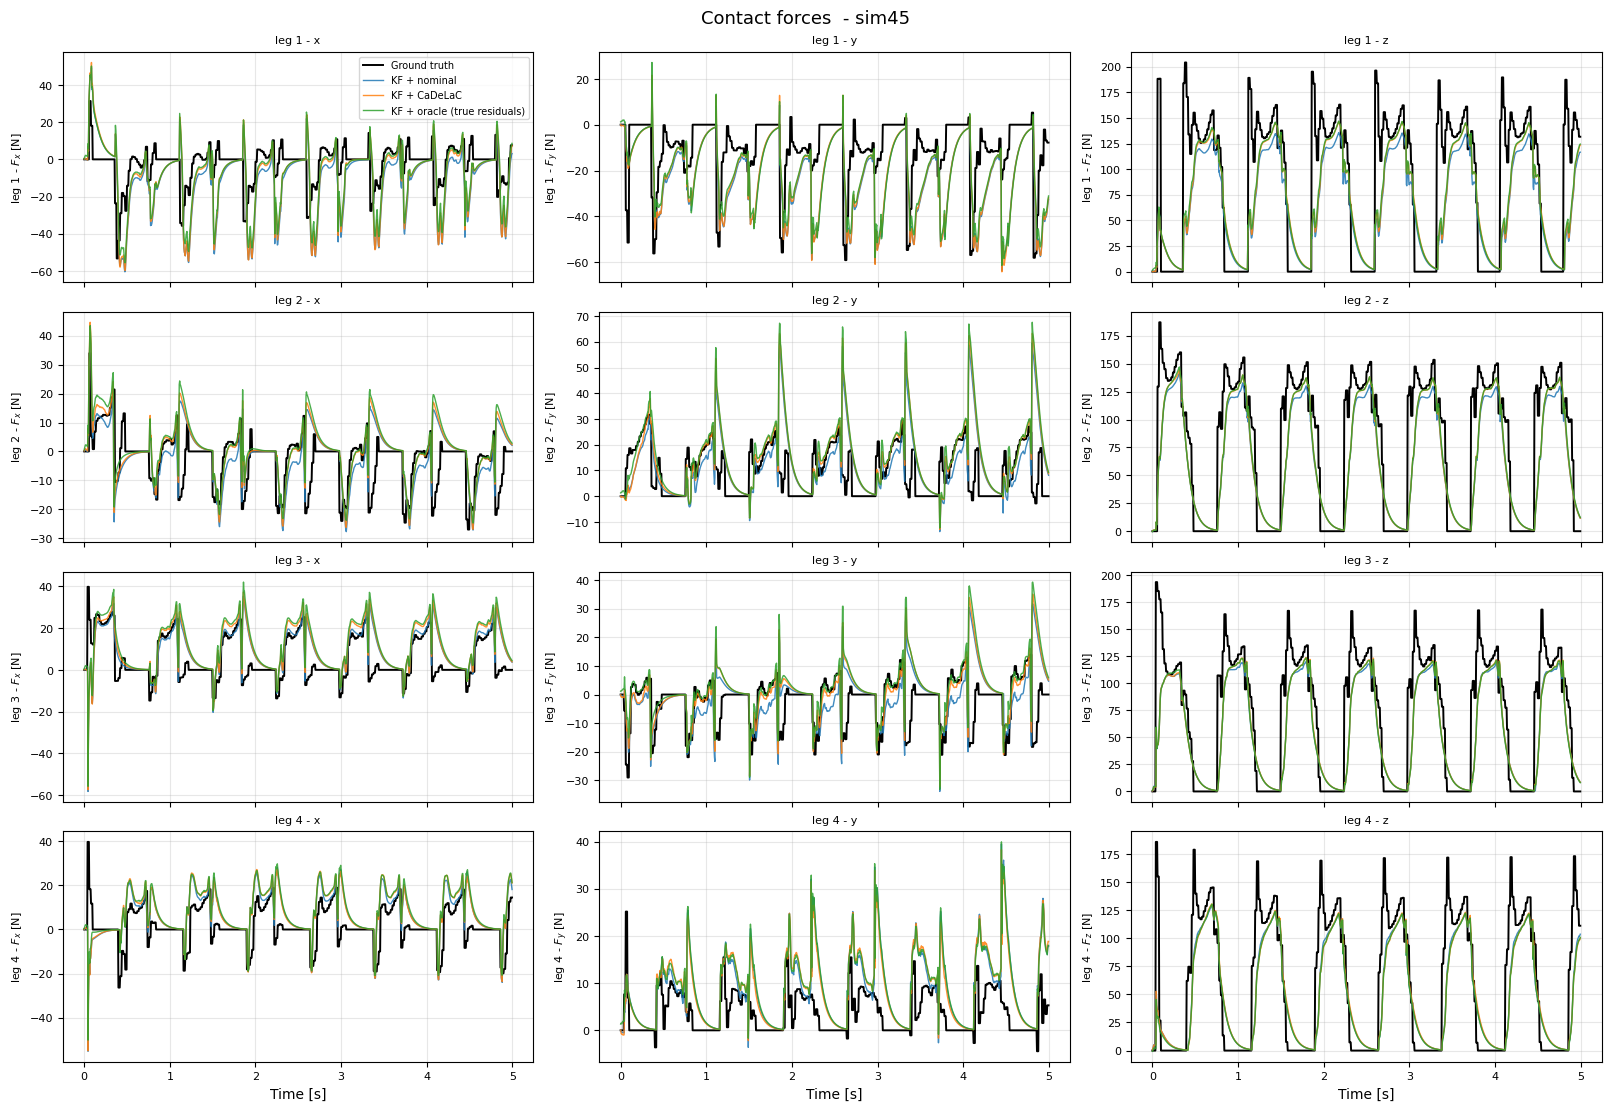

In [6]:
# Dieselbe Leiter, drei Kovarianz-/Sensor-Konfigurationen. Nur Q, R (und beim IMU-Fall
# der Beschleunigungseingang) aendern sich -- Modell, Datensatz und Lauf bleiben gleich.
#   R = [ -, R_v (Beinodometrie), R_w (Gyro), R_F (Kontaktkraefte) ]
#   Q = [ Q_pos, Q_vel, Q_angvel, Q_force ]
CONFIGS = {
    "deployed":  dict(Q=(1e-4, 1e-4, 1e-4, 1e-3), R=(0.1, 0.1,   1e-4, 1e-2)),
    "tuned":     dict(Q=(1e-4, 1e-4, 1e-4, 4.0),  R=(0.1, 6e-3,  1e-4, 1e+3)),
    "tuned+IMU": dict(Q=(1e-4, 1e-4, 1e-4, 4.0),  R=(0.1, 6e-3,  1e-4, 1e+3),
                      est_mode=2, use_imu=True),
}

print(f"{'Config':<12}{'Methode':<10}{'vel x':>8}{'vel y':>8}{'vel z':>8}{'Drift [%/m]':>13}")
print("-" * 59)
lo = rmse(next(iter(ladder.values()))["leg_odom_vel"], gt_v)
print(f"{'(Messung)':<12}{'leg odom':<10}{lo[0]:>8.3f}{lo[1]:>8.3f}{lo[2]:>8.3f}{'-':>13}")

ladders_qr = {}
gt_p = np.asarray(data["base_pos"]) - np.asarray(data["base_pos"])[0]
path_len = np.linalg.norm(np.diff(gt_p, axis=0), axis=1).sum()
for cfg_name, kw in CONFIGS.items():
    ladders_qr[cfg_name] = run_ladder_for_sim(data, cadelac_path, **kw)
    print("-" * 59)
    for v, r in ladders_qr[cfg_name].items():
        ve = rmse(r["vel_update"], gt_v)
        p = np.asarray(r["pos_update"]); p = p - p[0]
        drift = 100 * np.linalg.norm(p[-1] - gt_p[-1]) / path_len
        print(f"{cfg_name:<12}{v:<10}{ve[0]:>8.3f}{ve[1]:>8.3f}{ve[2]:>8.3f}{drift:>13.1f}")

# Zustandsplots fuer die abgestimmte Konfiguration (eigener Dateiname, ueberschreibt nichts)
figs_tuned = plot_state_comparison(data, ladders_qr["tuned"],
                                   sim_label=f" - sim{sim_num}", save_dir=fig_dir)